In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from heston.pinn.heston_pinn import HestonPINN
from heston.tree import HestonTreeFast

from config.heston_1d import *

In [2]:
seed = 42
pinn = HestonPINN(model_config, seed)
pinn.set_params(K, r, T, kappa, theta, sigma, rho, S_min, S_max, V_min, V_max)
pinn.set_loss_weights(loss_weights)

pinn.load(f'../../models/heston_pinn_1d/{seed}.pth')

In [3]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n
tree = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree.build_tree(0.01, V_max, 0.01, S_max, option_type="put", exercise_type="american")

In [4]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0.01, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
ht_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = pinn.predict(t, s_val, v_val).item()
        ht_prices[i, j] = tree.price(v_val, s_val, int(t * n - 0.5))

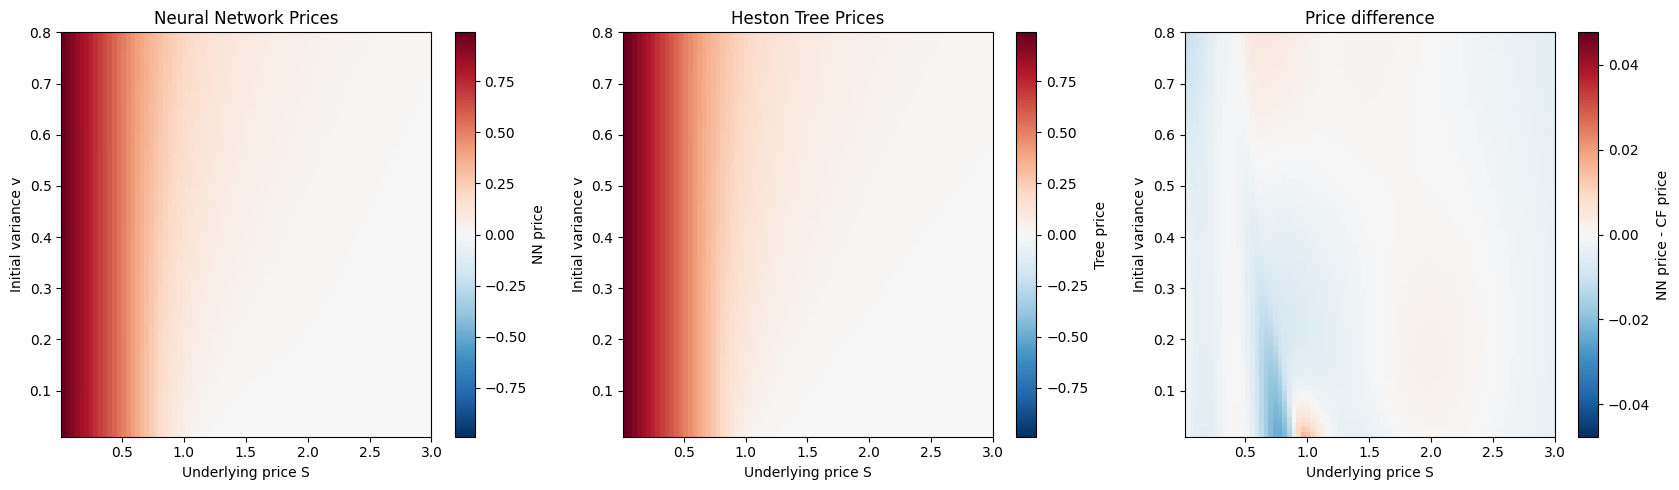

In [5]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(ht_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='Tree price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Heston Tree Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices
# diff = (nn_prices - ht_prices) / np.maximum(np.abs(ht_prices), 1e-4)  # Relative difference, avoid division by zero
# max_rel = 0.3
# diff = np.clip(diff, -max_rel, max_rel)  # Clip extreme values for better visualization
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()

plt.savefig('../../plots/heston/heston_american_put.png')
plt.show()

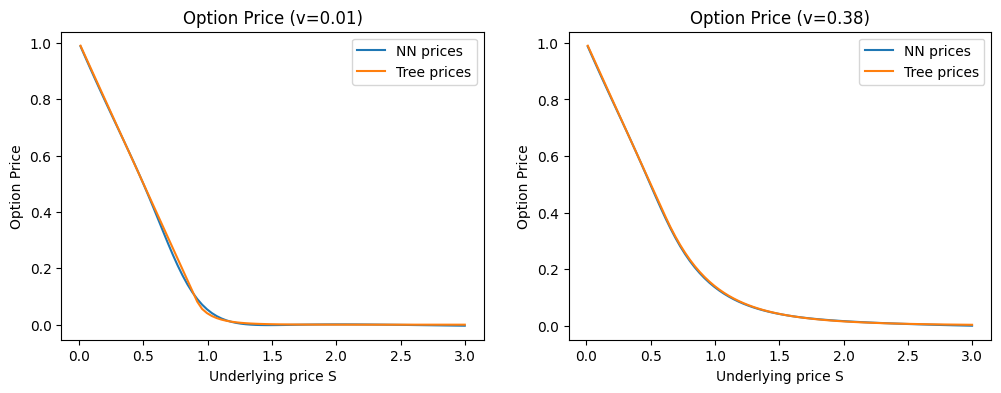

In [6]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
v_ind = 0
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.subplot(1, 2, 2)
v_ind = 37
plt.plot(Ss, nn_prices[v_ind, :], label='NN prices')
plt.plot(Ss, ht_prices[v_ind, :], label='Tree prices')
plt.xlabel('Underlying price S')
plt.ylabel('Option Price')
plt.title(f'Option Price (v={Vs[v_ind]:.2f})')
plt.legend()

plt.savefig('../../plots/heston/heston_american_put_fixed_vol.png')
plt.show()

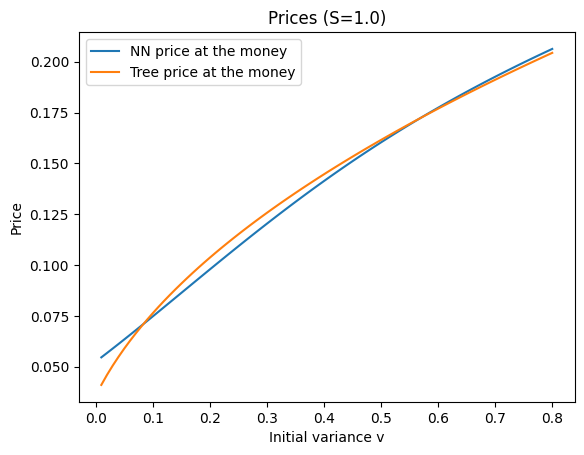

In [7]:
# Relative error at the money

S_ind = 26
# rel_err_atm = np.abs(nn_prices[:, S_ind] - ht_prices[:, S_ind]) / np.maximum(np.abs(ht_prices[:, S_ind]), 1e-4)
# plt.plot(Vs, rel_err_atm, label='Relative error at the money')
plt.plot(Vs, nn_prices[:, S_ind], label='NN price at the money')
plt.plot(Vs, ht_prices[:, S_ind], label='Tree price at the money')
plt.xlabel('Initial variance v')
plt.ylabel('Price')
# plt.ylabel('Relative error')
plt.title(f'Prices (S={Ss[S_ind]:.1f})')
plt.legend()
plt.savefig('../../plots/heston/heston_american_put_vary_vol')
plt.show()

## Free boundary

In [8]:
from utility.continuation_prob import compute_continuation_probs, estimate_contination_value_heston

In [9]:
num_V = 100
num_S = 100

Vs = np.linspace(0.01, V_max, num_V)
Ss = np.linspace(0.3, 1.0, num_S)
t = 0

In [10]:
continuation_values = np.zeros((num_V, num_S))
for i, V in enumerate(Vs):
    for j, S in enumerate(Ss):
        continuation_values[i, j] = estimate_contination_value_heston(pinn.model, t, S, V, r, kappa, theta, sigma, rho, n_paths=1000, h=0.01, seed=seed)
intrinsics = np.tile(np.maximum(K - Ss, 0), (num_V, 1))


/Users/jameswu/Documents/Imperial/Year 4/M4R/utility/continuation_prob.py:29: RuntimeWarning: divide by zero encountered in divide
  d = (continuation - intrinsics + shift) / intrinsics


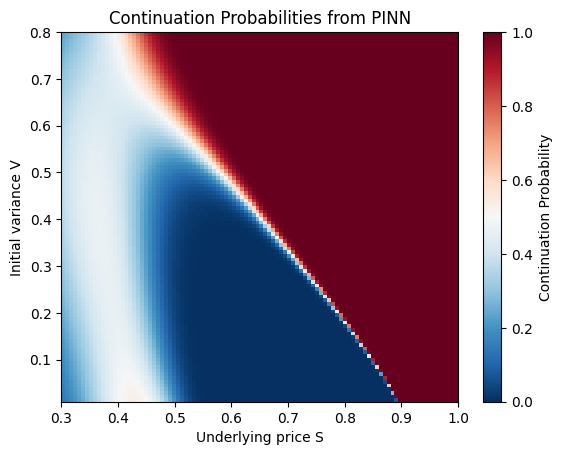

In [11]:
eps = 1e-2

cont_probs = compute_continuation_probs(continuation_values, intrinsics, eps)

# plot continuation probabilities
plt.imshow(cont_probs, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
           aspect='auto', origin='lower', cmap='RdBu_r')
plt.colorbar(label='Continuation Probability')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance V')
plt.title('Continuation Probabilities from PINN')
plt.show()